In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
data = pd.read_csv('healthinsurance.csv')
data.head()
data_copy = data.copy()

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            102 non-null    int64  
 1   Sex            102 non-null    object 
 2   BMI            102 non-null    float64
 3   Children       102 non-null    int64  
 4   Smoker         102 non-null    object 
 5   Region         102 non-null    object 
 6   Charges (INR)  102 non-null    int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 5.7+ KB


In [32]:
data['Region'].value_counts().sort_values()

Region
North    18
East     25
West     26
South    33
Name: count, dtype: int64

In [34]:
data['Children'].value_counts().sort_values()

Children
4     8
0    16
3    22
1    23
2    33
Name: count, dtype: int64

In [38]:
Clean_data = {
    'Sex' : {'Male' : 0, 'Female' : 1},
    'Smoker' : {'No' : 0, 'Yes' : 1},
    'Region' : {'North': 0, 'South': 1,'East': 2,'West': 3}
}
data_copy.replace(Clean_data, inplace=True)
print(data_copy)

     Age  Sex   BMI  Children  Smoker  Region  Charges (INR)
0     22    0  22.4         0       0       0          22000
1     30    1  27.8         1       1       1          45000
2     45    0  30.1         2       1       2          60000
3     50    1  25.6         3       0       3          50000
4     29    1  23.7         0       1       0          40000
..   ...  ...   ...       ...     ...     ...            ...
97    38    0  31.5         4       0       3          70000
98    50    1  26.7         1       1       1          55000
99    41    1  28.2         2       1       2          67000
100   29    0  29.1         0       0       1          43000
101   39    0  30.9         2       0       3          62000

[102 rows x 7 columns]


In [7]:
data_copy.describe()

,Age,Sex,BMI,Children,Smoker,Region,Charges (INR)
count,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000
mean,40.637255,0.490196,27.859804,1.833333,0.460784,1.578431,52245.098039
std,8.768518,0.502373,2.491819,1.169610,0.500921,1.057142,12468.920789
min,22.000000,0.000000,21.800000,0.000000,0.000000,0.000000,21000.000000
25%,34.000000,0.000000,26.400000,1.000000,0.000000,1.000000,45000.000000
50%,40.000000,0.000000,28.250000,2.000000,0.000000,1.500000,54000.000000
75%,48.000000,1.000000,29.875000,3.000000,1.000000,2.750000,61000.000000
max,60.000000,1.000000,32.500000,4.000000,1.000000,3.000000,78000.000000


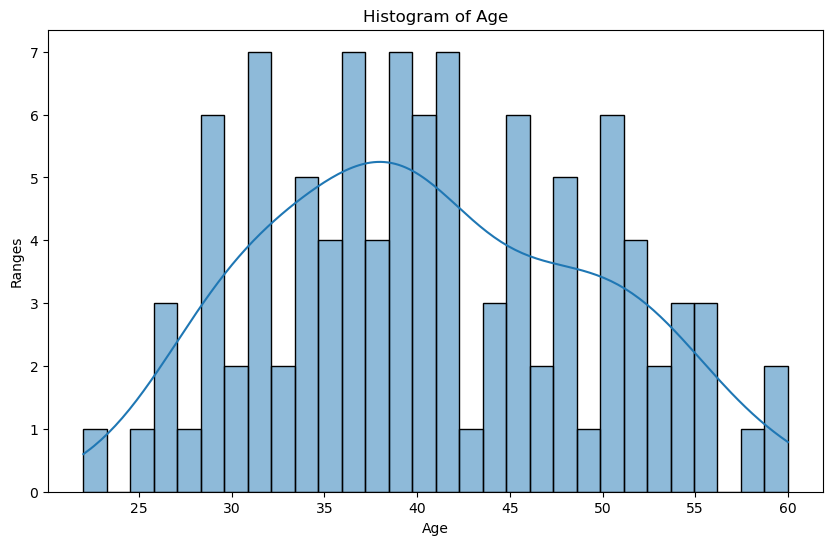

In [40]:
plt.figure(figsize=(10,6))  
sns.histplot(data_copy['Age'], bins=30, kde=True)
plt.title('Histogram of Age')
plt.xlabel('Age')
plt.ylabel('Ranges')
plt.show()

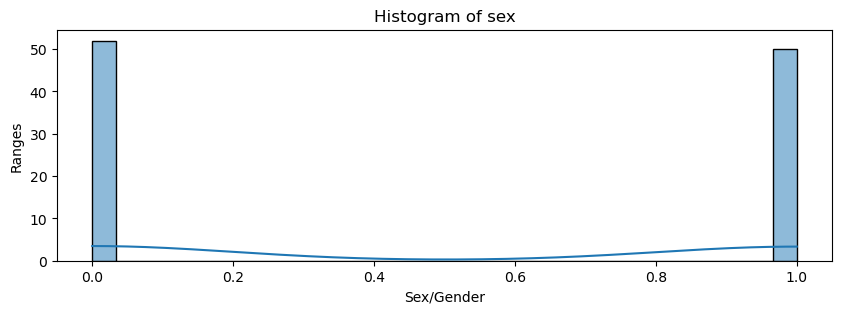

In [9]:
plt.figure(figsize=(10,3))
sns.histplot(data_copy['Sex'], bins=30, kde=True)
plt.title('Histogram of sex')
plt.xlabel('Sex/Gender')
plt.ylabel('Ranges')
plt.show()

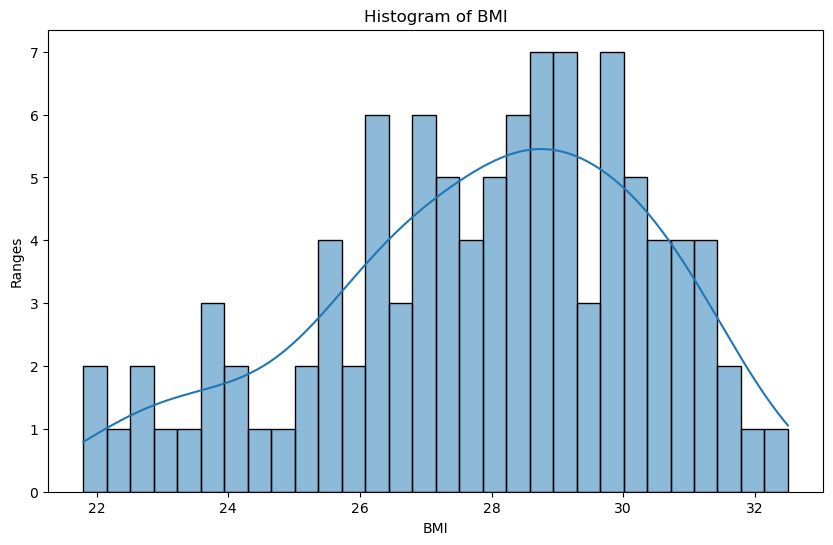

In [10]:
plt.figure(figsize=(10,6))
sns.histplot(data_copy['BMI'],bins=30,kde=True)
plt.title('Histogram of BMI')
plt.xlabel('BMI')
plt.ylabel('Ranges')
plt.show()

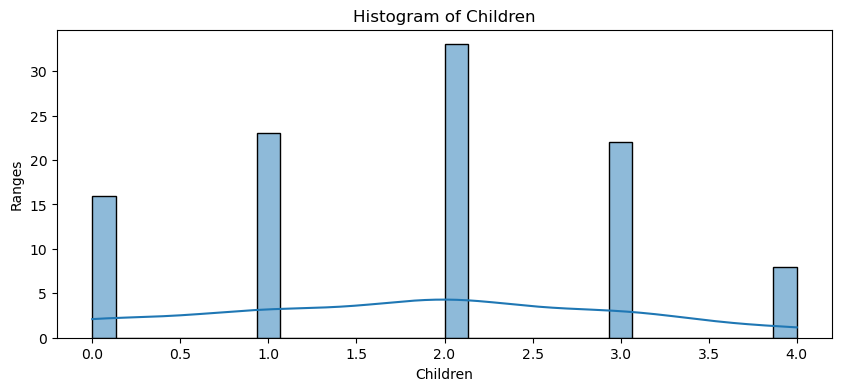

In [11]:
plt.figure(figsize=(10,4))
sns.histplot(data_copy['Children'],bins=30,kde=True)
plt.title('Histogram of Children')
plt.xlabel('Children')
plt.ylabel('Ranges')
plt.show()

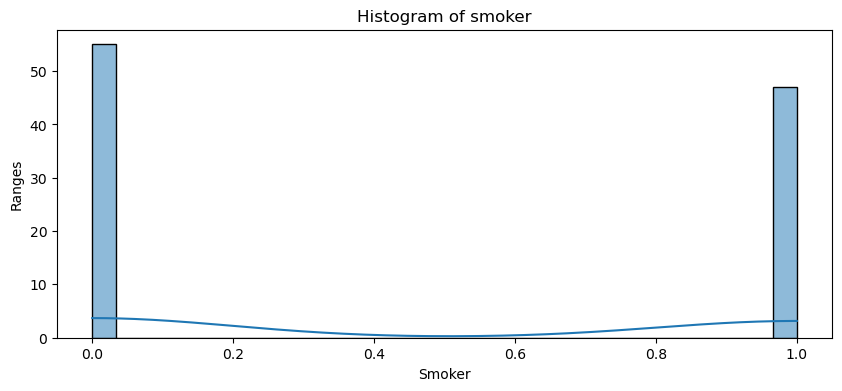

In [12]:
plt.figure(figsize=(10,4))
sns.histplot(data_copy['Smoker'],bins=30,kde=True)
plt.title('Histogram of smoker')
plt.xlabel('Smoker')
plt.ylabel('Ranges')
plt.show()

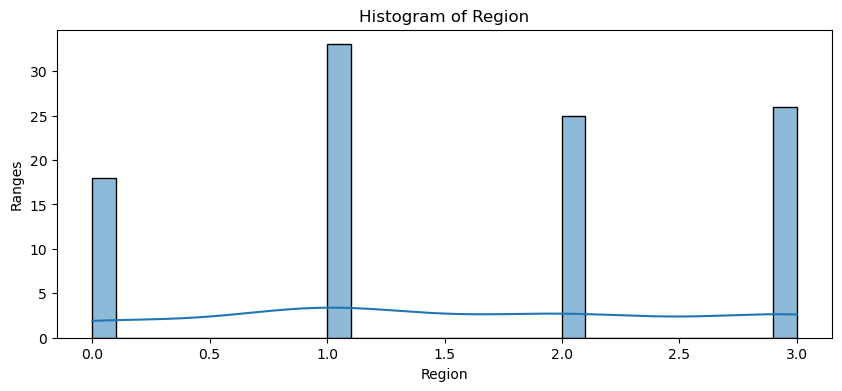

In [13]:
plt.figure(figsize=(10,4))
sns.histplot(data_copy['Region'],bins=30,kde=True)
plt.title('Histogram of Region')
plt.xlabel('Region')
plt.ylabel('Ranges')
plt.show()

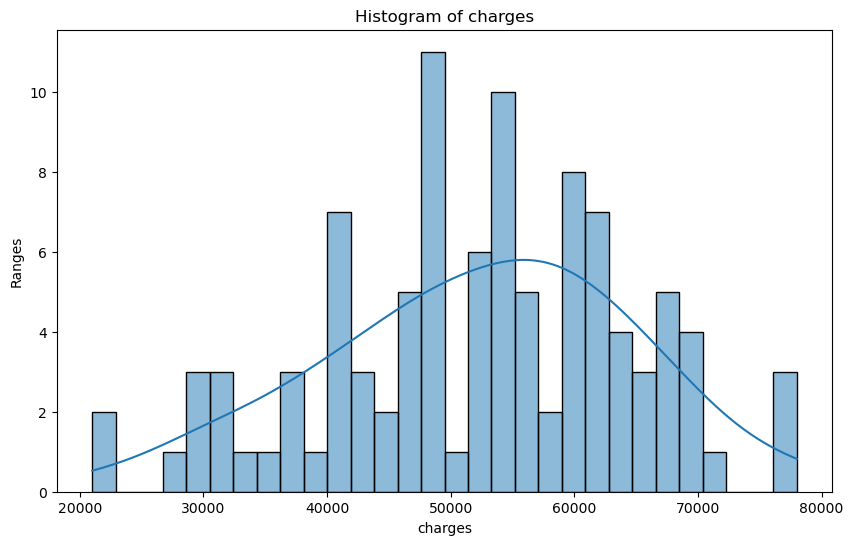

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(data_copy['Charges (INR)'],bins=30,kde=True)
plt.title('Histogram of charges')
plt.xlabel('charges')
plt.ylabel('Ranges')
plt.show()

In [42]:
print("CHECKING MISSING VALUES")
miss_val=data_copy.isnull().sum()
print("Missing values in each individyal column:")
print(miss_val)

CHECKING MISSING VALUES
Missing values in each individyal column:
Age              0
Sex              0
BMI              0
Children         0
Smoker           0
Region           0
Charges (INR)    0
dtype: int64


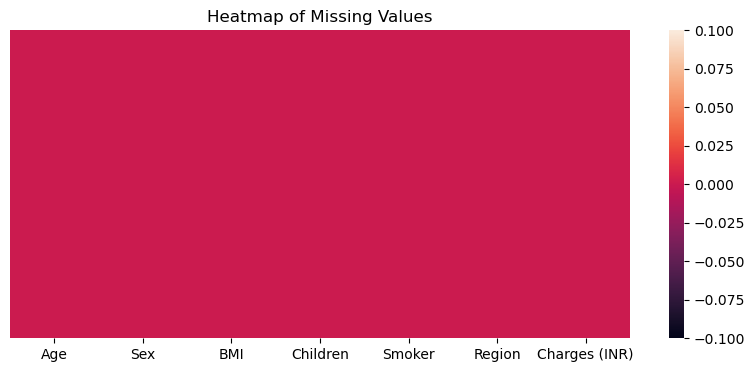

In [44]:
plt.figure(figsize=(10,4))
sns.heatmap(data_copy.isnull(),yticklabels=False,cbar=True)
plt.title("Heatmap of Missing Values")
plt.show()

Outliers Analysis by using box plot


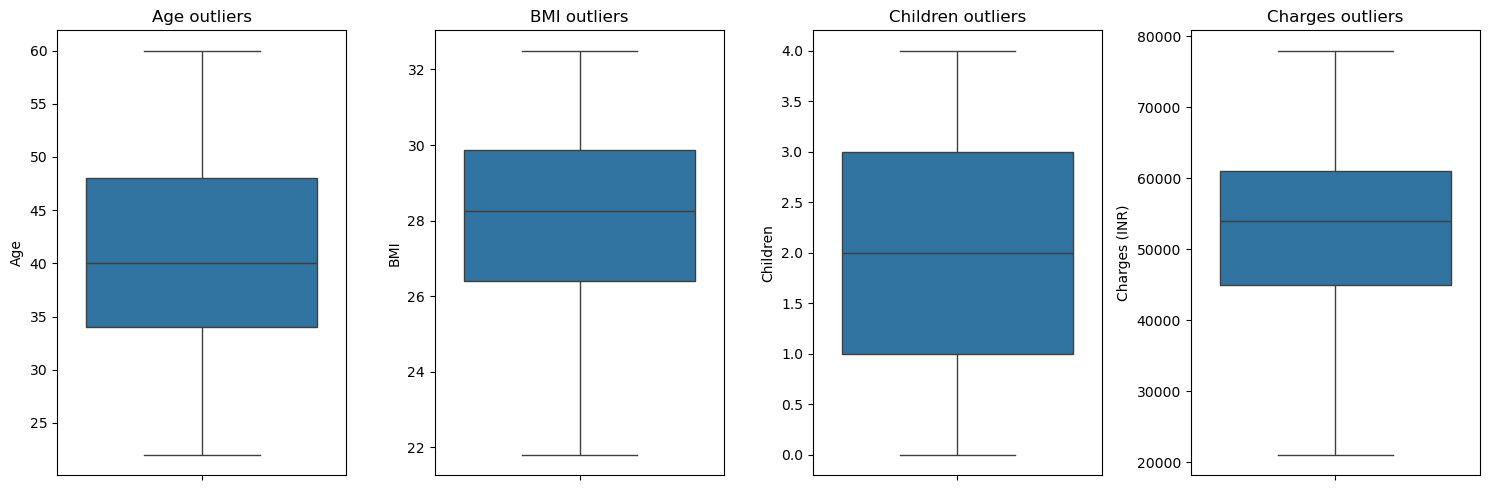

In [50]:
print("Outliers Analysis by using box plot")
plt.figure(figsize=(15,5))
plt.subplot(1,4,1)
sns.boxplot(y=data_copy["Age"])
plt.title('Age outliers')

plt.subplot(1,4,2)
sns.boxplot(y=data_copy['BMI'])
plt.title('BMI outliers')

plt.subplot(1,4,3)
sns.boxplot(y=data_copy['Children'])
plt.title('Children outliers')

plt.subplot(1,4,4)
sns.boxplot(y=data_copy['Charges (INR)'])
plt.title('Charges outliers')

plt.tight_layout()
plt.show()

In [72]:
numerical_cols = ['Age', 'BMI', 'Children', 'Charges (INR)']

for column in numerical_cols:
    Q1 = data_copy[column].quantile(0.25)
    Q3 = data_copy[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data_copy[(data_copy[column] < lower_bound) | 
                        (data_copy[column] > upper_bound)][column]
    
    print(f"\nOutliers in {column}:")
    print(f"Number of outliers: {len(outliers)}")
    print(f"Percentage of outliers: {(len(outliers)/len(data_copy)*100):.2f}%")
    print(f"Outlier range: {outliers.min():.2f} to {outliers.max():.2f}")


Outliers in Age:
Number of outliers: 0
Percentage of outliers: 0.00%
Outlier range: nan to nan

Outliers in BMI:
Number of outliers: 0
Percentage of outliers: 0.00%
Outlier range: nan to nan

Outliers in Children:
Number of outliers: 0
Percentage of outliers: 0.00%
Outlier range: nan to nan

Outliers in Charges (INR):
Number of outliers: 0
Percentage of outliers: 0.00%
Outlier range: nan to nan


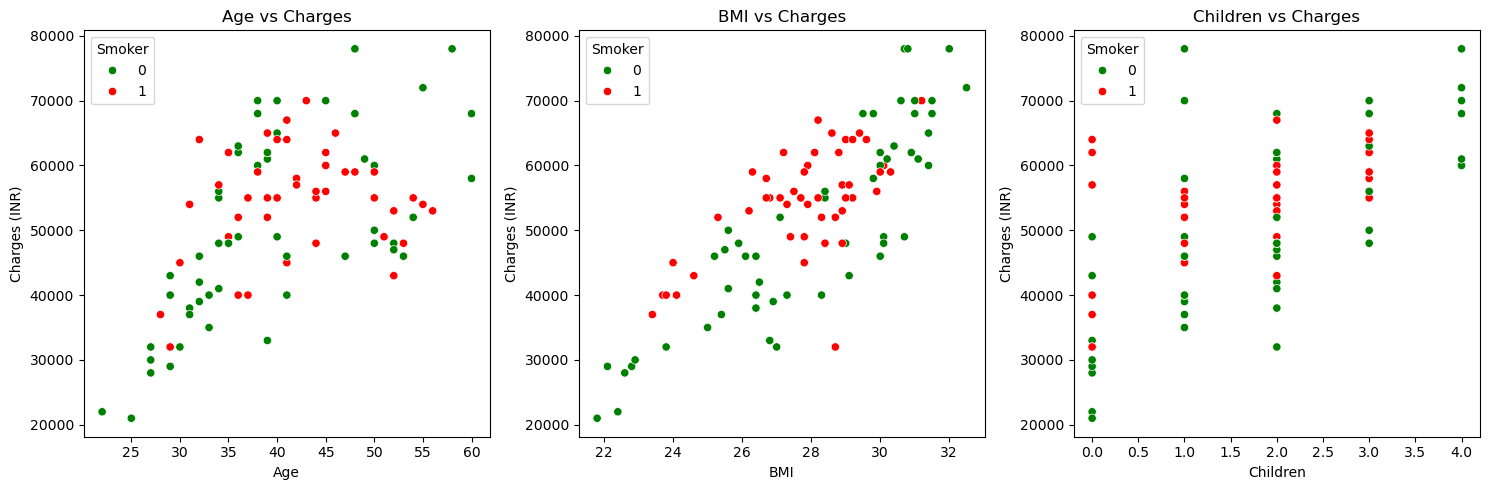

In [74]:
plt.figure(figsize=(15, 5))

# age vs charges
plt.subplot(1, 3, 1)
sns.scatterplot(data=data_copy, x='Age', y='Charges (INR)', 
                hue='Smoker', palette=['green', 'red'])
plt.title('Age vs Charges')

# bmi vs charges
plt.subplot(1, 3, 2)
sns.scatterplot(data=data_copy, x='BMI', y='Charges (INR)', 
                hue='Smoker', palette=['green', 'red'])
plt.title('BMI vs Charges')

# children vs charges
plt.subplot(1, 3, 3)
sns.scatterplot(data=data_copy, x='Children', y='Charges (INR)', 
                hue='Smoker', palette=['green', 'red'])
plt.title('Children vs Charges')

plt.tight_layout()
plt.show()